In [1]:
#Load dataset
import pandas as pd

from pathlib import Path

file_name = "hotel_booking_cancellation_dataset.xlsx"

data_path = Path(file_name)

print("Current dataset path:", data_path)

print("File exists:", data_path.exists())

df = pd.read_excel(data_path)

print("Dataset loaded successfully!")

df.head()

Current dataset path: hotel_booking_cancellation_dataset.xlsx
File exists: True
Dataset loaded successfully!


,Booking_ID,Customer_Age,Booking_Channel,Room_Type,Number_of_Nights,Number_of_Guests,Booking_Lead_Time_Days,Total_Booking_Value,Previous_Bookings,Special_Requests,Deposit_Paid,Loyalty_Member,Travel_Purpose,Booking_Cancelled
0,1.0,52.0,Website,Standard,10.0,5.0,175.0,3033.0,2.0,2.0,No,Yes,Event,No
1,2.0,18.0,Third-party Platform,Standard,10.0,4.0,66.0,410.0,7.0,2.0,Yes,No,Family,No
2,3.0,59.0,Website,Standard,4.0,1.0,177.0,2922.0,9.0,3.0,Yes,Yes,Leisure,No
3,4.0,75.0,Phone,Family,3.0,5.0,74.0,453.0,2.0,3.0,No,No,Business,No
4,5.0,77.0,Website,Standard,10.0,3.0,11.0,2782.0,6.0,4.0,Yes,No,Event,No


In [2]:
#Inspect dataset
print('The number of rows and columns: ')
df.shape

The number of rows and columns: 


(376, 14)

In [3]:
print('The names of all columns: ')
df.columns

The names of all columns: 


Index(['Booking_ID', 'Customer_Age', 'Booking_Channel', 'Room_Type',
       'Number_of_Nights', 'Number_of_Guests', 'Booking_Lead_Time_Days',
       'Total_Booking_Value', 'Previous_Bookings', 'Special_Requests',
       'Deposit_Paid', 'Loyalty_Member', 'Travel_Purpose',
       'Booking_Cancelled'],
      dtype='object')

In [4]:
print('General information about the dataset:')
df.info()

General information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Booking_ID              376 non-null    float64
 1   Customer_Age            369 non-null    float64
 2   Booking_Channel         370 non-null    object 
 3   Room_Type               370 non-null    object 
 4   Number_of_Nights        376 non-null    float64
 5   Number_of_Guests        376 non-null    float64
 6   Booking_Lead_Time_Days  376 non-null    float64
 7   Total_Booking_Value     369 non-null    float64
 8   Previous_Bookings       376 non-null    float64
 9   Special_Requests        376 non-null    float64
 10  Deposit_Paid            370 non-null    object 
 11  Loyalty_Member          376 non-null    object 
 12  Travel_Purpose          370 non-null    object 
 13  Booking_Cancelled       376 non-null    object 
dtypes: 

In [5]:
print('The data type of each column: ')
df.dtypes

The data type of each column: 


Booking_ID                float64
Customer_Age              float64
Booking_Channel            object
Room_Type                  object
Number_of_Nights          float64
Number_of_Guests          float64
Booking_Lead_Time_Days    float64
Total_Booking_Value       float64
Previous_Bookings         float64
Special_Requests          float64
Deposit_Paid               object
Loyalty_Member             object
Travel_Purpose             object
Booking_Cancelled          object
dtype: object

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Booking_ID                0
Customer_Age              7
Booking_Channel           6
Room_Type                 6
Number_of_Nights          0
Number_of_Guests          0
Booking_Lead_Time_Days    0
Total_Booking_Value       7
Previous_Bookings         0
Special_Requests          0
Deposit_Paid              6
Loyalty_Member            0
Travel_Purpose            6
Booking_Cancelled         0
dtype: int64


In [7]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
6


In [8]:
#Understand the business problem
business_problem = "A company wants to predict which customers are likely to cancel their booking."
ml_problem = "This is a classification problem because we want to predict whether the customer will cancel the booking or not."
prediction_goal = "Predict whether a customer will cancel the booking: Yes or No."

print("Business Problem:\n", business_problem)

print("\nMachine Learning Problem:\n", ml_problem)

print("\nPrediction Goal:\n", prediction_goal)

Business Problem:
 A company wants to predict which customers are likely to cancel their booking.

Machine Learning Problem:
 This is a classification problem because we want to predict whether the customer will cancel the booking or not.

Prediction Goal:
 Predict whether a customer will cancel the booking: Yes or No.


In [9]:
#Basic Data Cleaning: Duplicated and missing values
df_clean = df.copy()
print("Original dataset shape:")
print(df_clean.shape)

df_clean = df_clean.drop_duplicates()
print("Dataset shape after removing duplicate rows:")
print(df_clean.shape)
print("\nNumber of duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Original dataset shape:
(376, 14)
Dataset shape after removing duplicate rows:
(370, 14)

Number of duplicate rows after cleaning:
0


In [10]:
numeric_columns = [
    "Customer_Age",
    "Number_of_Nights",
    "Number_of_Guests",
    "Booking_Lead_Time_Days",
    "Total_Booking_Value",
    "Previous_Bookings",
    "Special_Requests"
]

categorical_columns = [
    "Booking_Channel",
    "Room_Type",
    "Deposit_Paid",
    "Loyalty_Member",
    "Travel_Purpose"
]

In [11]:
for column in numeric_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

In [12]:
for column in categorical_columns:
    mode_value = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(mode_value)

In [13]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\nCleaned dataset preview:")
display(df_clean.head())

Missing values after cleaning:
Booking_ID                0
Customer_Age              0
Booking_Channel           0
Room_Type                 0
Number_of_Nights          0
Number_of_Guests          0
Booking_Lead_Time_Days    0
Total_Booking_Value       0
Previous_Bookings         0
Special_Requests          0
Deposit_Paid              0
Loyalty_Member            0
Travel_Purpose            0
Booking_Cancelled         0
dtype: int64

Cleaned dataset preview:


,Booking_ID,Customer_Age,Booking_Channel,Room_Type,Number_of_Nights,Number_of_Guests,Booking_Lead_Time_Days,Total_Booking_Value,Previous_Bookings,Special_Requests,Deposit_Paid,Loyalty_Member,Travel_Purpose,Booking_Cancelled
0,1.0,52.0,Website,Standard,10.0,5.0,175.0,3033.0,2.0,2.0,No,Yes,Event,No
1,2.0,18.0,Third-party Platform,Standard,10.0,4.0,66.0,410.0,7.0,2.0,Yes,No,Family,No
2,3.0,59.0,Website,Standard,4.0,1.0,177.0,2922.0,9.0,3.0,Yes,Yes,Leisure,No
3,4.0,75.0,Phone,Family,3.0,5.0,74.0,453.0,2.0,3.0,No,No,Business,No
4,5.0,77.0,Website,Standard,10.0,3.0,11.0,2782.0,6.0,4.0,Yes,No,Event,No


In [14]:
#Convert Customer Age to integer
df_clean["Customer_Age"] = df_clean["Customer_Age"].astype(int)
df_clean["Number_of_Nights"] = df_clean["Number_of_Nights"].astype(int)
df_clean["Number_of_Guests"] = df_clean["Number_of_Guests"].astype(int)
df_clean["Booking_Lead_Time_Days"] = df_clean["Booking_Lead_Time_Days"].astype(int)
df_clean["Total_Booking_Value"] = df_clean["Total_Booking_Value"].astype(float)
df_clean["Previous_Bookings"] = df_clean["Previous_Bookings"].astype(int)
df_clean["Special_Requests"] = df_clean["Special_Requests"].astype(int)

df_clean["Booking_Channel"] = df_clean["Booking_Channel"].astype("category")
df_clean["Room_Type"] = df_clean["Room_Type"].astype("category")
df_clean["Deposit_Paid"] = df_clean["Deposit_Paid"].astype("category")
df_clean["Loyalty_Member"] = df_clean["Loyalty_Member"].astype("category")
df_clean["Travel_Purpose"] = df_clean["Travel_Purpose"].astype("category")

print(df_clean.dtypes)

Booking_ID                 float64
Customer_Age                 int64
Booking_Channel           category
Room_Type                 category
Number_of_Nights             int64
Number_of_Guests             int64
Booking_Lead_Time_Days       int64
Total_Booking_Value        float64
Previous_Bookings            int64
Special_Requests             int64
Deposit_Paid              category
Loyalty_Member            category
Travel_Purpose            category
Booking_Cancelled           object
dtype: object


In [15]:
#Replace the original dataframe with the cleaned dataframe
df = df_clean.copy()

In [16]:
#Identify the features and target variable
feature_columns = [
    "Customer_Age",
    "Booking_Channel",
    "Room_Type",
    "Number_of_Nights",
    "Number_of_Guests",
    "Booking_Lead_Time_Days",
    "Total_Booking_Value",
    "Previous_Bookings",
    "Special_Requests",
    "Deposit_Paid",
    "Loyalty_Member",
    "Travel_Purpose"
]

target_column = "Booking_Cancelled"

#Define X and y
X = df[feature_columns]
y = df[target_column]

print("Feature Columns:\n")
display(X.head())
print("Shape of X:", X.shape)

print("\nTarget Column:\n")
display(y.head())
print("Shape of y:", y.shape)
print("\nTarget values:")
print(df[target_column].value_counts())

Feature Columns:



,Customer_Age,Booking_Channel,Room_Type,Number_of_Nights,Number_of_Guests,Booking_Lead_Time_Days,Total_Booking_Value,Previous_Bookings,Special_Requests,Deposit_Paid,Loyalty_Member,Travel_Purpose
0,52,Website,Standard,10,5,175,3033.0,2,2,No,Yes,Event
1,18,Third-party Platform,Standard,10,4,66,410.0,7,2,Yes,No,Family
2,59,Website,Standard,4,1,177,2922.0,9,3,Yes,Yes,Leisure
3,75,Phone,Family,3,5,74,453.0,2,3,No,No,Business
4,77,Website,Standard,10,3,11,2782.0,6,4,Yes,No,Event


Shape of X: (370, 12)

Target Column:



0    No
1    No
2    No
3    No
4    No
Name: Booking_Cancelled, dtype: object

Shape of y: (370,)

Target values:
No     345
Yes     25
Name: Booking_Cancelled, dtype: int64


In [17]:
y = y.map({"No": 0, "Yes": 1})
print("Target value counts after conversion:")
print(y.value_counts())

Target value counts after conversion:
0    345
1     25
Name: Booking_Cancelled, dtype: int64


In [18]:
#Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:")
print(X_train.shape)

print("X_test shape:")
print(X_test.shape)

print("y_train shape:")
print(y_train.shape)

print("y_test shape:")
print(y_test.shape)

X_train shape:
(296, 12)
X_test shape:
(74, 12)
y_train shape:
(296,)
y_test shape:
(74,)


In [19]:
#Apply preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_columns = [
    "Customer_Age",
    "Number_of_Nights",
    "Number_of_Guests",
    "Booking_Lead_Time_Days",
    "Total_Booking_Value",
    "Previous_Bookings",
    "Special_Requests"
]

categorical_columns = [
    "Booking_Channel",
    "Room_Type",
    "Deposit_Paid",
    "Loyalty_Member",
    "Travel_Purpose"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)


X_train_preprocessed = preprocessor.fit_transform(X_train)
print("X_train preprocessing completed!")

X_test_preprocessed = preprocessor.transform(X_test)
print("X_test preprocessing completed!")

print("Summary of preprocessing shapes:")
print("X_train before preprocessing:", X_train.shape)
print("X_train after preprocessing:", X_train_preprocessed.shape)
print("X_test before preprocessing:", X_test.shape)
print("X_test after preprocessing:", X_test_preprocessed.shape)

X_train preprocessing completed!
X_test preprocessing completed!
Summary of preprocessing shapes:
X_train before preprocessing: (296, 12)
X_train after preprocessing: (296, 24)
X_test before preprocessing: (74, 12)
X_test after preprocessing: (74, 24)


In [20]:
#Train a simple baseline model using Logistic Regression
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_preprocessed, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
y_pred_logistic = logistic_model.predict(X_test_preprocessed)
print("Predictions completed successfully!")
print("First 15 predictions:")
print(y_pred_logistic[:15])

Predictions completed successfully!
First 15 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [22]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})

display(comparison_df.head(15))

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [24]:
accuracy = accuracy_score(y_test, y_pred_logistic)
print("Accuracy:", accuracy)

Accuracy: 0.9324324324324325


In [25]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[67  2]
 [ 3  2]]


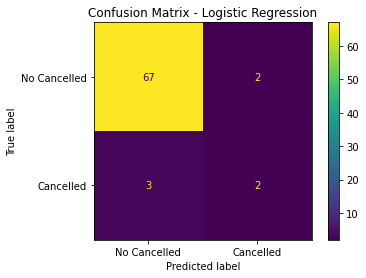

In [26]:
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No Cancelled", "Cancelled"]
)

display_cm.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [27]:
precision = precision_score(y_test, y_pred_logistic, zero_division=0)
recall = recall_score(y_test, y_pred_logistic, zero_division=0)
f1 = f1_score(y_test, y_pred_logistic, zero_division=0)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.5
Recall: 0.4
F1-score: 0.4444444444444445


In [28]:
print("Classification Report:")
print(classification_report(y_test, y_pred_logistic, target_names=["No Cancelled", "Cancelled"], zero_division=0))

Classification Report:
              precision    recall  f1-score   support

No Cancelled       0.96      0.97      0.96        69
   Cancelled       0.50      0.40      0.44         5

    accuracy                           0.93        74
   macro avg       0.73      0.69      0.70        74
weighted avg       0.93      0.93      0.93        74



In [29]:
print('''
- What is your model trying to predict?
The model predicts whether a hotel customer will cancel their booking. 
This is a binary classification problem where the output is either 1 (cancelled) or 0 (not cancelled), based on information available at the time of booking.

- What dataset did you use?
The dataset that I used for this purpose was "hotel_booking_cancellation_dataset", which contains customer and booking information such as 
age, room type, booking channel, lead time, total value, and loyalty status, along with a label indicating whether the booking was ultimately cancelled.

- What features and target did you select?
Features: 'Customer_Age', 'Booking_Channel', 'Room_Type', 'Number_of_Nights', 'Number_of_Guests',
'Booking_Lead_Time_Days', 'Total_Booking_Value', 'Previous_Bookings', 'Special_Requests', 'Deposit_Paid',
'Loyalty_Member', 'Travel_Purpose',

Target: 'Booking_Cancelled', encoded as 0 (No) and 1 (Yes).

- What result did you obtain?
The Logistic Regression model achieved an accuracy of approximately 93%, indicating that it correctly classifies the majority of bookings. 
Precision, recall, and F1-score were also calculated to assess performance beyond accuracy, particularly for the minority cancellation class.

- One limitation of your model or dataset
The dataset is small, so it may not generalize well to real-world customer data
''')


- What is your model trying to predict?
The model predicts whether a hotel customer will cancel their booking. 
This is a binary classification problem where the output is either 1 (cancelled) or 0 (not cancelled), based on information available at the time of booking.

- What dataset did you use?
The dataset that I used for this purpose was "hotel_booking_cancellation_dataset", which contains customer and booking information such as 
age, room type, booking channel, lead time, total value, and loyalty status, along with a label indicating whether the booking was ultimately cancelled.

- What features and target did you select?
Features: 'Customer_Age', 'Booking_Channel', 'Room_Type', 'Number_of_Nights', 'Number_of_Guests',
'Booking_Lead_Time_Days', 'Total_Booking_Value', 'Previous_Bookings', 'Special_Requests', 'Deposit_Paid',
'Loyalty_Member', 'Travel_Purpose',

Target: 'Booking_Cancelled', encoded as 0 (No) and 1 (Yes).

- What result did you obtain?
The Logistic Regression model a